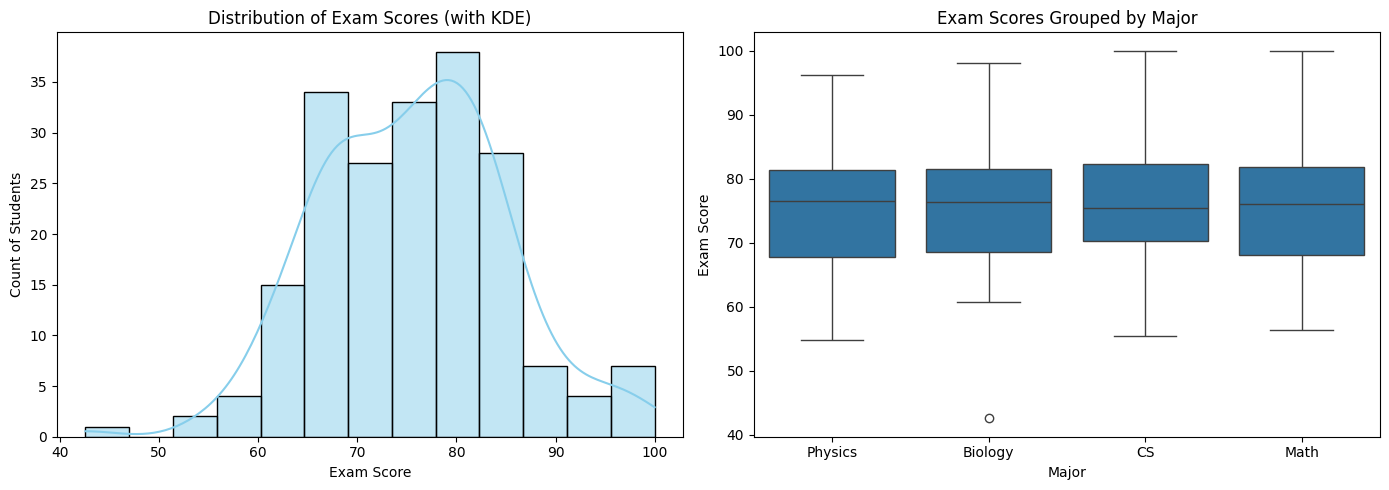

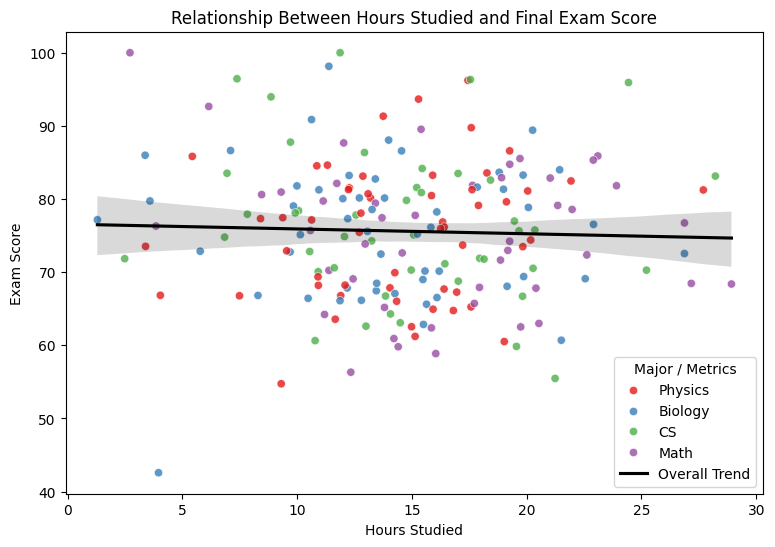

/tmp/ipykernel_31320/2414685348.py:106: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='performance', y='exam_score', order=category_order, ax=axes[1, 1], palette='muted')


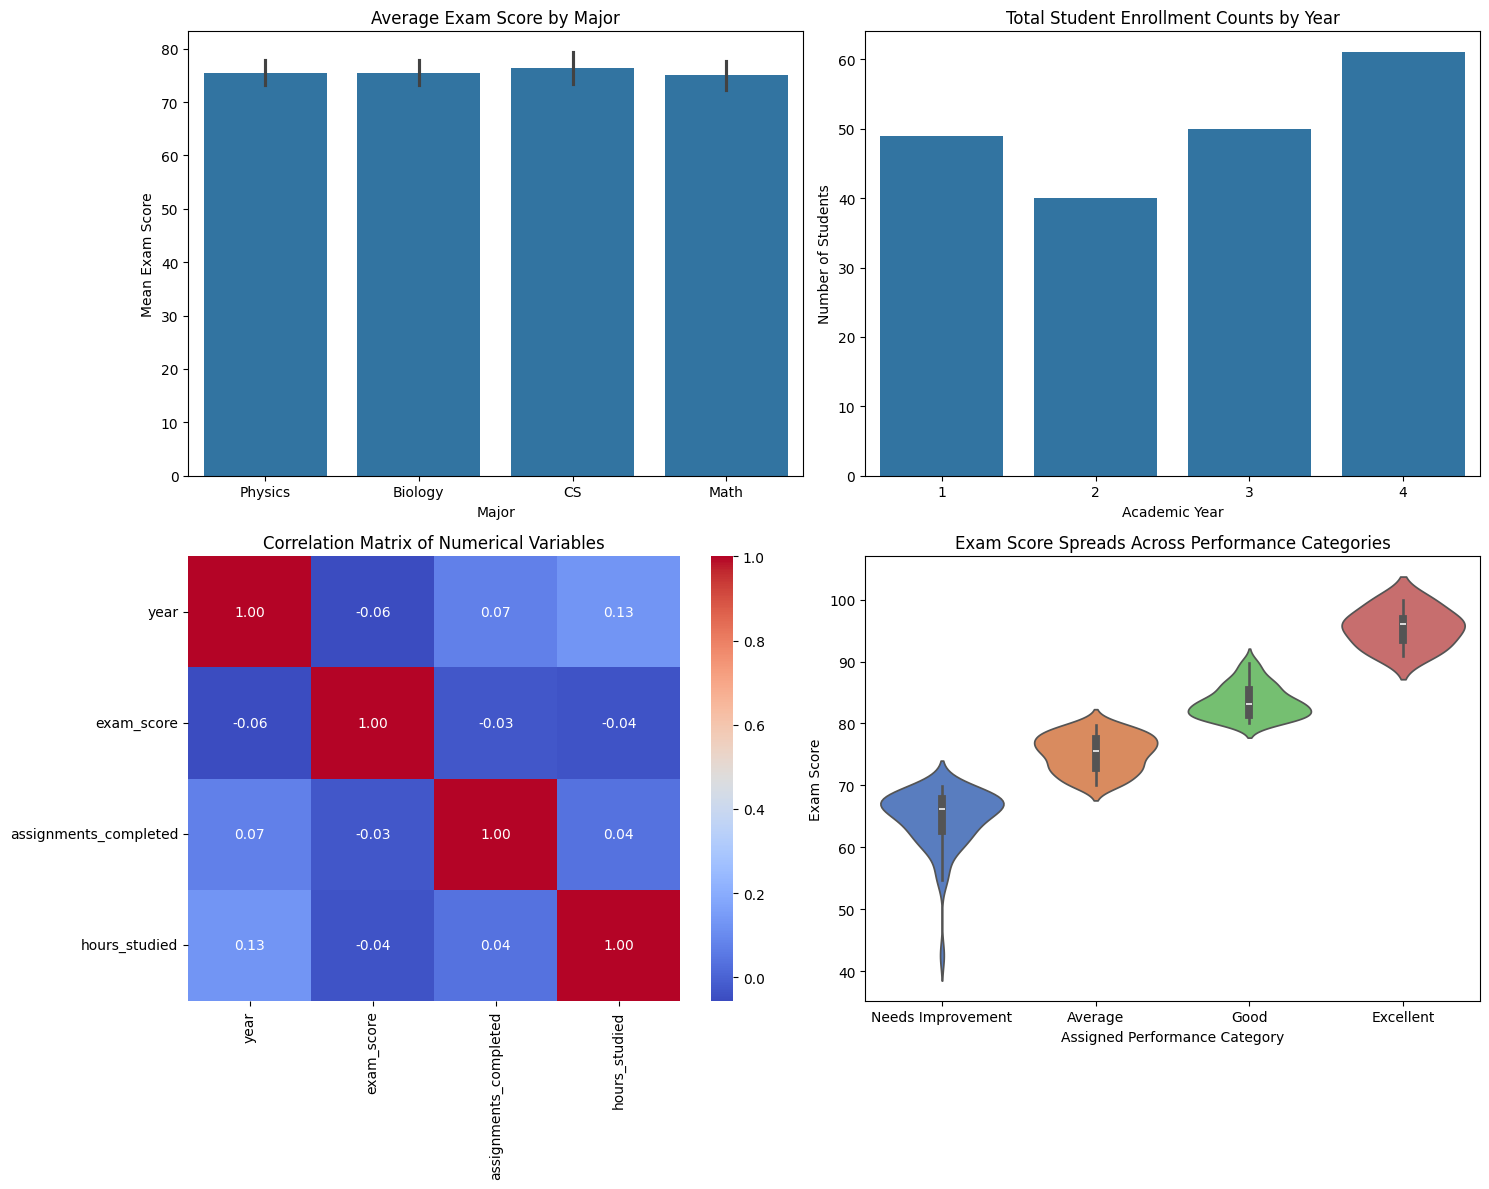

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#From Exercise 5
np.random.seed(42)
n_students = 200
data = {
    'student_id': range(1000, 1000 + n_students),
    'major': np.random.choice(['CS', 'Math', 'Physics', 'Biology'], n_students),
    'year': np.random.choice([1, 2, 3, 4], n_students),
    'exam_score': np.random.normal(75, 10, n_students).clip(0, 100),
    'assignments_completed': np.random.randint(0, 11, n_students),
    'hours_studied': np.random.normal(15, 5, n_students).clip(1, 40)
}
df = pd.DataFrame(data)

#performance summary table
df['performance'] = 'Needs Improvement'
df.loc[(df['exam_score'] >= 70) & (df['exam_score'] <= 80), 'performance'] = 'Average'
df.loc[(df['exam_score'] > 80) & (df['exam_score'] <= 90), 'performance'] = 'Good'
df.loc[df['exam_score'] > 90, 'performance'] = 'Excellent'


# Task 1: Distribution Visualization (8 points)
# TODO: Create a figure with 2 subplots side by side
#        Left: Histogram of exam scores with KDE overlay
#        Right: Box plot of exam scores by major
# TODO: Add appropriate titles, labels, and styling

# Setting up the 1x2 subplot container
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plotting the left histogram with a trend line curve
sns.histplot(data=df, x='exam_score', kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Exam Scores (with KDE)')
axes[0].set_xlabel('Exam Score')
axes[0].set_ylabel('Count of Students')

# Plotting the right boxplot broken down by student majors
sns.boxplot(data=df, x='major', y='exam_score', ax=axes[1])
axes[1].set_title('Exam Scores Grouped by Major')
axes[1].set_xlabel('Major')
axes[1].set_ylabel('Exam Score')

plt.tight_layout()
plt.show()


# Task 2: Relationship Visualization (8 points)
# TODO: Create a scatter plot of hours_studied vs exam_score
# TODO: Color points by major
# TODO: Add a regression line
# TODO: Include appropriate legends, titles, and axis labels

# Initializing a standalone scatter canvas
plt.figure(figsize=(9, 6))

# Generating the dots colored by major categories
sns.scatterplot(data=df, x='hours_studied', y='exam_score', hue='major', palette='Set1', alpha=0.8)

# Overlaying a single global linear regression line across all data points
sns.regplot(data=df, x='hours_studied', y='exam_score', scatter=False, color='black', label='Overall Trend')

# Final formatting for annotations and structural descriptions
plt.title('Relationship Between Hours Studied and Final Exam Score')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.legend(title='Major / Metrics')
plt.show()


# Task 3: Advanced Dashboard (9 points)
# TODO: Create a 2x2 subplot figure containing:
#        1. Bar chart: Average exam score by major
#        2. Count plot: Number of students by year
#        3. Heat map: Correlation matrix of numerical columns
#        4. Violin plot: Exam score distribution by performance category
# TODO: Adjust layout, add titles, and ensure readability

# Setting up a large 2x2 multi-plot display matrix
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Top-Left: Bar Chart tracking default average score distributions
sns.barplot(data=df, x='major', y='exam_score', ax=axes[0, 0])
axes[0, 0].set_title('Average Exam Score by Major')
axes[0, 0].set_xlabel('Major')
axes[0, 0].set_ylabel('Mean Exam Score')

# 2. Top-Right: Count Plot evaluating class sizes per academic year
sns.countplot(data=df, x='year', ax=axes[0, 1],)
axes[0, 1].set_title('Total Student Enrollment Counts by Year')
axes[0, 1].set_xlabel('Academic Year')
axes[0, 1].set_ylabel('Number of Students')

# 3. Bottom-Left: Heat Map charting numerical relationships
numerical_columns = df[['year', 'exam_score', 'assignments_completed', 'hours_studied']]
correlation_matrix = numerical_columns.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[1, 0])
axes[1, 0].set_title('Correlation Matrix of Numerical Variables')

# 4. Bottom-Right: Violin Plot exploring grade distributions across bins
# Ordering categories explicitly to make the visual progression logical
category_order = ['Needs Improvement', 'Average', 'Good', 'Excellent']
sns.violinplot(data=df, x='performance', y='exam_score', order=category_order, ax=axes[1, 1], palette='muted')
axes[1, 1].set_title('Exam Score Spreads Across Performance Categories')
axes[1, 1].set_xlabel('Assigned Performance Category')
axes[1, 1].set_ylabel('Exam Score')

# Optimizing whitespace distribution to stop any title overlapping
plt.tight_layout()
plt.show()